# MethylSeg HM450K vs WGBS Region Overlap

This notebook summarizes tumor-only MethylSeg PMD overlap from the HM450K perspective.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "repo_paths.py").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate repo_paths.py from the current working directory.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
import numpy as np
import pandas as pd
import seaborn as sns

from figures.utils.figures_utils import (
    get_methylseg_tumor_samples,
    load_methylseg_hm450k_overlap_hm450k_region_metrics,
    load_methylseg_hm450k_overlap_sample_summary,
    load_methylseg_hm450k_overlap_wgbs_region_metrics,
)
from repo_paths import FIGURE_RESULTS_DIR

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150


In [2]:
from colors import ANNOTATION_COLORS, NEUTRAL_COLORS, REGION_CATEGORY_COLORS, REPLICATE_COLORS

THRESHOLD_REQ = 1
TUMOR_SAMPLE_IDS = get_methylseg_tumor_samples()
SELECTED_SAMPLE = "WGBS_colon-primary-tumor_1_meth"
COLON_REPLICATE_IDS = [
    "WGBS_colon-primary-tumor_1_meth",
    "WGBS_colon-primary-tumor_2_meth",
    "WGBS_colon-primary-tumor_3_meth",
]
SAVE_FIGURES = False
OUTPUT_DIR = FIGURE_RESULTS_DIR / "methylseg_region_overlap_figures"

CATEGORY_ORDER = ["microarray_unique",  "shared", "microarray_missed",]
CATEGORY_LABELS = {
    "microarray_unique": "Microarray unique",
    "microarray_missed": "WGBS unique",
    "shared": "Shared",
}
CATEGORY_COLORS = REGION_CATEGORY_COLORS.copy()
WGBS_REPLICATE_COLORS = REPLICATE_COLORS["wgbs"].copy()
HM450K_REPLICATE_COLORS = REPLICATE_COLORS["hm450k"].copy()

PROBE_COUNT_XMAX = 1000
REGION_LENGTH_XMAX = 0.6e7
PROBE_COUNT_BINS = 150
REGION_LENGTH_BINS = 150
AVG_METHYLATION_BINS = 150
PROBE_REDUCTION_BINS = 250
PROBE_REDUCTION_XMIN = 0.0
PROBE_REDUCTION_XMAX = 1.0
PROBE_PRESENT_ZOOM_BINS = 20
PROBE_PRESENT_ZOOM_XMIN = 0.0
PROBE_PRESENT_ZOOM_XMAX = 0.2
METRIC_SPECS = [
    {
        "key": "hm450k_probe_count",
        "title": "HM450K probes in region",
        "label": "Probe count",
        "hist_bins": PROBE_COUNT_BINS,
        "xmin": None,
        "xmax": PROBE_COUNT_XMAX,
    },
    {
        "key": "region_length_bp",
        "title": "Region length",
        "label": "Length (bp)",
        "hist_bins": REGION_LENGTH_BINS,
        "xmin": None,
        "xmax": REGION_LENGTH_XMAX,
    },
    {
        "key": "avg_methylation",
        "title": "Average methylation",
        "label": "Mean methylation",
        "hist_bins": AVG_METHYLATION_BINS,
        "xmin": None,
        "xmax": None,
    },
    {
        "key": "probe_present_fraction",
        "title": "HM450K CpG fraction present relative to WGBS",
        "table_title": "CpG fraction present",
        "label": "Fraction of WGBS CpGs present in HM450K",
        "hist_bins": PROBE_REDUCTION_BINS,
        "xmin": PROBE_REDUCTION_XMIN,
        "xmax": PROBE_REDUCTION_XMAX,
    },
]

if SELECTED_SAMPLE not in TUMOR_SAMPLE_IDS:
    raise ValueError(f"SELECTED_SAMPLE={SELECTED_SAMPLE!r} is not in the tumor sample set.")

if any("normal" in sample.lower() for sample in TUMOR_SAMPLE_IDS):
    raise AssertionError("Tumor-only sample set unexpectedly includes normal samples.")


In [3]:
def threshold_label(threshold_req):
    if isinstance(threshold_req, int):
        return f"{threshold_req} bp overlap"
    return f"{threshold_req:.0%} of the HM450K region"


def savefig_if_enabled(fig, filename):
    if not SAVE_FIGURES:
        return None
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / filename
    fig.savefig(out_path, bbox_inches="tight")
    return out_path


def build_histogram_df(hm450k_df, wgbs_df):
    hm_plot_df = hm450k_df.loc[:, [
        "sample_id",
        "category",
        "region_length_bp",
        "hm450k_probe_count",
        "wgbs_cpg_count",
        "probe_reduction_fraction",
        "avg_methylation",
    ]].copy()
    wgbs_plot_df = wgbs_df.loc[:, [
        "sample_id",
        "category",
        "region_length_bp",
        "hm450k_probe_count",
        "wgbs_cpg_count",
        "probe_reduction_fraction",
        "avg_methylation",
    ]].copy()
    plot_df = pd.concat([hm_plot_df, wgbs_plot_df], ignore_index=True)
    plot_df["probe_present_fraction"] = 1.0 - plot_df["probe_reduction_fraction"]
    plot_df["category"] = pd.Categorical(
        plot_df["category"],
        categories=CATEGORY_ORDER,
        ordered=True,
    )
    plot_df["category_label"] = plot_df["category"].map(CATEGORY_LABELS)
    return plot_df


def plot_overlap_venn(ax, summary_row):
    venn = venn2(
        subsets=(
            int(summary_row["hm450k_microarray_unique_regions"]),
            int(summary_row["wgbs_microarray_missed_regions"]),
            int(summary_row["hm450k_shared_regions"]),
        ),
        set_labels=("HM450K-called regions", "WGBS-called regions"),
        ax=ax,
    )

    subset_colors = {
        "10": CATEGORY_COLORS["microarray_unique"],
        "01": CATEGORY_COLORS["microarray_missed"],
        "11": CATEGORY_COLORS["shared"],
    }
    for subset_id, color in subset_colors.items():
        patch = venn.get_patch_by_id(subset_id)
        if patch is not None:
            patch.set_color(color)
            patch.set_alpha(0.55)
            patch.set_edgecolor(color)
            patch.set_linewidth(1.5)

    for subset_id in ("10", "01", "11"):
        label = venn.get_label_by_id(subset_id)
        if label is not None:
            label.set_fontsize(13)
            label.set_fontweight("bold")

    for set_id in ("A", "B"):
        label = venn.get_label_by_id(set_id)
        if label is not None:
            label.set_fontsize(11)

    ax.text(
        0.5,
        -0.08,
        "Shared counts use the HM450K-centered overlap threshold.",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
    )


def load_called_regions(sample_id, platform):
    path = (
        PROJECT_ROOT / "results" / "01_region_calling_analysis" / "methylseg"
        / sample_id / "out" / platform / "summary_files" / "segments_cleaned_PMD.bed"
    )
    df = pd.read_csv(
        path,
        sep="	",
        header=None,
        usecols=[0, 1, 2],
        names=["chrom", "start", "end"],
    )
    df["chrom"] = df["chrom"].astype(str)
    return df.sort_values(["chrom", "start", "end"]).reset_index(drop=True)


def build_overlap_membership_df(region_tables):
    set_names = list(region_tables)
    combined = []
    for set_name, df in region_tables.items():
        tmp = df.loc[:, ["chrom", "start", "end"]].copy()
        tmp["set_name"] = set_name
        combined.append(tmp)
    combined_df = pd.concat(combined, ignore_index=True)
    combined_df = combined_df.sort_values(["chrom", "start", "end", "set_name"]).reset_index(drop=True)

    loci_rows = []
    for chrom, chrom_df in combined_df.groupby("chrom", sort=False):
        rows = chrom_df.to_dict("records")
        current_start = None
        current_end = None
        current_members = set()
        for row in rows:
            start = int(row["start"])
            end = int(row["end"])
            set_name = row["set_name"]
            if current_start is None:
                current_start = start
                current_end = end
                current_members = {set_name}
                continue
            if start < current_end:
                current_end = max(current_end, end)
                current_members.add(set_name)
            else:
                ordered_members = tuple(name for name in set_names if name in current_members)
                loci_rows.append({
                    "chrom": chrom,
                    "start": current_start,
                    "end": current_end,
                    "members": ordered_members,
                })
                current_start = start
                current_end = end
                current_members = {set_name}
        if current_start is not None:
            ordered_members = tuple(name for name in set_names if name in current_members)
            loci_rows.append({
                "chrom": chrom,
                "start": current_start,
                "end": current_end,
                "members": ordered_members,
            })

    membership_df = pd.DataFrame(loci_rows)
    for set_name in set_names:
        membership_df[set_name] = membership_df["members"].map(
            lambda members, name=set_name: name in members
        )
    membership_df["subset_key"] = membership_df[set_names].apply(
        lambda row: "".join("1" if bool(value) else "0" for value in row),
        axis=1,
    )
    return membership_df, set_names


def build_subset_count_df(region_tables):
    membership_df, set_names = build_overlap_membership_df(region_tables)
    subset_count_df = (
        membership_df.groupby("subset_key", as_index=False)
        .size()
        .rename(columns={"size": "n_loci"})
    )
    subset_count_df = subset_count_df.loc[
        subset_count_df["subset_key"].str.contains("1")
    ].copy()
    for idx, set_name in enumerate(set_names):
        subset_count_df[set_name] = subset_count_df["subset_key"].str[idx] == "1"
    subset_count_df["n_sets"] = subset_count_df[set_names].sum(axis=1)
    subset_count_df["label"] = subset_count_df[set_names].apply(
        lambda row: " + ".join(name for name, present in row.items() if present),
        axis=1,
    )
    subset_count_df = subset_count_df.sort_values(
        ["n_loci", "n_sets"],
        ascending=[False, False],
    ).reset_index(drop=True)
    return membership_df, subset_count_df, set_names


def venn3_subset_dict(subset_count_df):
    counts = dict(zip(subset_count_df["subset_key"], subset_count_df["n_loci"]))
    return {
        key: int(counts.get(key, 0))
        for key in ["100", "010", "110", "001", "101", "011", "111"]
    }


def plot_replicate_venn3(
    ax,
    subset_count_df,
    set_labels,
    set_colors,
    title,
    subset_label_positions=None,
    set_label_positions=None,
):
    venn = venn3(subsets=venn3_subset_dict(subset_count_df), set_labels=set_labels, ax=ax)
    singleton_colors = {"100": set_colors[0], "010": set_colors[1], "001": set_colors[2]}
    for subset_id, color in singleton_colors.items():
        patch = venn.get_patch_by_id(subset_id)
        if patch is not None:
            patch.set_color(color)
            patch.set_alpha(0.55)
            patch.set_edgecolor(color)
            patch.set_linewidth(1.4)
    for subset_id in ["110", "101", "011", "111"]:
        patch = venn.get_patch_by_id(subset_id)
        if patch is not None:
            patch.set_color(ANNOTATION_COLORS["venn_overlap_fill"])
            patch.set_alpha(0.38)
            patch.set_edgecolor(ANNOTATION_COLORS["venn_overlap_fill"])
            patch.set_linewidth(1.2)

    ax.set_aspect("equal", adjustable="box")
    for subset_id in ["100", "010", "110", "001", "101", "011", "111"]:
        label = venn.get_label_by_id(subset_id)
        if label is not None:
            label.set_fontsize(10)
            label.set_fontweight("bold")
            if subset_label_positions and subset_id in subset_label_positions:
                label.set_position(subset_label_positions[subset_id])
                label.set_ha("center")
                label.set_va("center")
    for set_id in ["A", "B", "C"]:
        label = venn.get_label_by_id(set_id)
        if label is not None:
            label.set_fontsize(11)
            if set_label_positions and set_id in set_label_positions:
                label.set_position(set_label_positions[set_id])
                label.set_ha("center")
                label.set_va("center")
    ax.set_title(title)
    return venn


def plot_multiset_membership(bar_ax, matrix_ax, subset_count_df, set_names, set_color_map, title, max_rows=20):
    plot_df = subset_count_df.head(max_rows).iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))

    bar_ax.barh(y, plot_df["n_loci"], color=CATEGORY_COLORS["shared"], alpha=0.85)
    bar_ax.set_yticks(y)
    bar_ax.set_yticklabels([])
    bar_ax.set_xlabel("Merged loci")
    bar_ax.set_title(title)
    bar_ax.grid(axis="x", alpha=0.3)
    for yi, count in zip(y, plot_df["n_loci"]):
        bar_ax.text(count, yi, f" {int(count):,}", va="center", ha="left", fontsize=8)

    for yi in y:
        matrix_ax.scatter(
            np.arange(len(set_names)),
            np.full(len(set_names), yi),
            color=NEUTRAL_COLORS["soft_gray"],
            s=20,
            zorder=1,
        )
    for yi, (_, row) in zip(y, plot_df.iterrows()):
        included = [idx for idx, set_name in enumerate(set_names) if row[set_name]]
        if len(included) > 1:
            matrix_ax.plot(
                [min(included), max(included)],
                [yi, yi],
                color=NEUTRAL_COLORS["text_gray"],
                linewidth=1.0,
                zorder=2,
            )
        for idx in included:
            set_name = set_names[idx]
            matrix_ax.scatter(idx, yi, color=set_color_map[set_name], s=80, zorder=3)

    matrix_ax.set_xticks(np.arange(len(set_names)))
    matrix_ax.set_xticklabels(set_names, rotation=35, ha="right")
    matrix_ax.set_yticks(y)
    matrix_ax.set_yticklabels([])
    matrix_ax.set_xlabel("Samples")
    # matrix_ax.set_ylabel("Membership pattern")
    
    matrix_ax.grid(False)


def overlapping_hist(ax, plot_df, metric_col, title, xlabel, bins=30, xmin=None, xmax=None):
    finite_df = plot_df.loc[np.isfinite(plot_df[metric_col]), ["category", metric_col]].copy()
    if finite_df.empty:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        if xmin is not None:
            ax.set_xlim(left=xmin)
        if xmax is not None:
            ax.set_xlim(right=xmax)
        return

    if xmin is not None:
        finite_df = finite_df.loc[finite_df[metric_col] >= xmin].copy()
    if xmax is not None:
        finite_df = finite_df.loc[finite_df[metric_col] <= xmax].copy()
    if finite_df.empty:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        if xmin is not None:
            ax.set_xlim(left=xmin)
        if xmax is not None:
            ax.set_xlim(right=xmax)
        return

    if metric_col in {"avg_methylation", "probe_reduction_fraction", "probe_present_fraction"}:
        lower = xmin if xmin is not None else 0
        upper = xmax if xmax is not None else 1
        bin_edges = np.linspace(lower, upper, int(bins) + 1)
    elif xmin is not None or xmax is not None:
        lower = xmin if xmin is not None else 0
        upper = xmax if xmax is not None else float(finite_df[metric_col].max())
        bin_edges = np.linspace(lower, upper, int(bins) + 1)
    else:
        bin_edges = np.histogram_bin_edges(finite_df[metric_col].to_numpy(dtype=float), bins=bins)

    for category in CATEGORY_ORDER:
        category_values = finite_df.loc[finite_df["category"] == category, metric_col].to_numpy(dtype=float)
        if category_values.size == 0:
            continue
        label = f"{CATEGORY_LABELS[category]} (n={category_values.size:,})"
        ax.hist(
            category_values,
            bins=bin_edges,
            density=True,
            alpha=0.4,
            color=CATEGORY_COLORS[category],
            edgecolor=CATEGORY_COLORS[category],
            linewidth=1.2,
            label=label,
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    ax.legend(frameon=False, fontsize=9)


def prepare_metric_df(plot_df, metric_spec, include_category_label=False):
    metric_col = metric_spec["key"]
    columns = ["category", metric_col]
    if include_category_label:
        columns.append("category_label")
    metric_df = plot_df.loc[np.isfinite(plot_df[metric_col]), columns].copy()
    xmin = metric_spec.get("xmin")
    xmax = metric_spec.get("xmax")
    if xmin is not None:
        metric_df = metric_df.loc[metric_df[metric_col] >= xmin].copy()
    if xmax is not None:
        metric_df = metric_df.loc[metric_df[metric_col] <= xmax].copy()
    return metric_df


def format_metric_value(metric_key, value):
    if not np.isfinite(value):
        return "NA"
    if metric_key in {"avg_methylation", "probe_reduction_fraction", "probe_present_fraction"}:
        return f"{value:.3f}"
    return f"{value:,.0f}"


def category_boxplot(ax, plot_df, metric_spec):
    metric_col = metric_spec["key"]
    metric_df = prepare_metric_df(plot_df, metric_spec)
    data = []
    labels = []
    colors = []
    counts = []
    for category in CATEGORY_ORDER:
        values = metric_df.loc[metric_df["category"] == category, metric_col].to_numpy(dtype=float)
        if values.size == 0:
            continue
        data.append(values)
        labels.append(CATEGORY_LABELS[category])
        colors.append(CATEGORY_COLORS[category])
        counts.append(values.size)
    if not data:
        ax.set_title(metric_spec["title"])
        ax.set_ylabel(metric_spec["label"])
        return
    box = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.5)
    for median in box["medians"]:
        median.set_color(NEUTRAL_COLORS["black"])
        median.set_linewidth(1.5)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels([f"{label}\n(n={n:,})" for label, n in zip(labels, counts)], rotation=12, ha="right")
    ax.set_title(metric_spec["title"])
    ax.set_ylabel(metric_spec["label"])
    ax.grid(axis="y", alpha=0.4)


def build_metric_summary_table_df(plot_df):
    rows = []
    for metric_spec in METRIC_SPECS:
        metric_col = metric_spec["key"]
        metric_df = prepare_metric_df(plot_df, metric_spec)
        for category in CATEGORY_ORDER:
            values = metric_df.loc[metric_df["category"] == category, metric_col].to_numpy(dtype=float)
            if values.size == 0:
                continue
            rows.append({
                "Metric": metric_spec.get("table_title", metric_spec["title"]),
                "Category": CATEGORY_LABELS[category],
                "Min": format_metric_value(metric_col, float(np.min(values))),
                "Median": format_metric_value(metric_col, float(np.median(values))),
                "Mean": format_metric_value(metric_col, float(np.mean(values))),
                "Max": format_metric_value(metric_col, float(np.max(values))),
            })
    return pd.DataFrame(rows)


def plot_metric_summary_table(plot_df, figure_title, output_name):
    summary_df = build_metric_summary_table_df(plot_df)
    fig_height = max(5, 0.42 * len(summary_df) + 1.8)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    ax.axis("off")
    table = ax.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor(ANNOTATION_COLORS["table_header_alt_fill"])
        elif col == 1:
            category_label = summary_df.iloc[row - 1]["Category"]
            for category_key, label in CATEGORY_LABELS.items():
                if label == category_label:
                    cell.set_facecolor(CATEGORY_COLORS[category_key])
                    cell.set_alpha(0.25)
                    break
    ax.set_title(figure_title, pad=16)
    savefig_if_enabled(fig, output_name)
    return fig, ax, summary_df


def plot_histogram_grid(plot_df, figure_title, output_name):
    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    axes = axes.ravel()
    for ax, metric_spec in zip(axes[:4], METRIC_SPECS):
        overlapping_hist(
            ax,
            plot_df,
            metric_spec["key"],
            metric_spec["title"],
            metric_spec["label"],
            bins=metric_spec["hist_bins"],
            xmin=metric_spec["xmin"],
            xmax=metric_spec["xmax"],
        )
    overlapping_hist(
        axes[4],
        plot_df,
        "probe_present_fraction",
        f"CpG fraction present zoom ({PROBE_PRESENT_ZOOM_XMIN}-{PROBE_PRESENT_ZOOM_XMAX})",
        "Fraction of WGBS CpGs present in HM450K",
        bins=PROBE_PRESENT_ZOOM_BINS,
        xmin=PROBE_PRESENT_ZOOM_XMIN,
        xmax=PROBE_PRESENT_ZOOM_XMAX,
    )
    axes[5].axis("off")
    fig.suptitle(figure_title, y=0.995)
    fig.subplots_adjust(top=0.90, wspace=0.28, hspace=0.35)
    savefig_if_enabled(fig, output_name)
    return fig, axes


def plot_boxplot_grid(plot_df, figure_title, output_name):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.ravel()
    for ax, metric_spec in zip(axes, METRIC_SPECS):
        category_boxplot(ax, plot_df, metric_spec)
    fig.suptitle(figure_title, y=0.995)
    fig.subplots_adjust(top=0.90, wspace=0.28, hspace=0.42)
    savefig_if_enabled(fig, output_name)
    return fig, axes


In [4]:
sample_summary_df = load_methylseg_hm450k_overlap_sample_summary(
    sample_ids=TUMOR_SAMPLE_IDS,
    threshold_req=THRESHOLD_REQ,
)
hm450k_region_df = load_methylseg_hm450k_overlap_hm450k_region_metrics(
    sample_ids=TUMOR_SAMPLE_IDS,
    threshold_req=THRESHOLD_REQ,
)
wgbs_region_df = load_methylseg_hm450k_overlap_wgbs_region_metrics(
    sample_ids=TUMOR_SAMPLE_IDS,
    threshold_req=THRESHOLD_REQ,
)
histogram_df = build_histogram_df(hm450k_region_df, wgbs_region_df)
selected_summary = sample_summary_df.loc[sample_summary_df["sample_id"] == SELECTED_SAMPLE].iloc[0]
aggregate_value_cols = [
    col for col in sample_summary_df.columns
    if col not in {"sample_id", "threshold_kind", "threshold_value"}
]
aggregate_summary = pd.Series({
    "sample_id": "All tumor samples",
    "threshold_kind": sample_summary_df["threshold_kind"].iloc[0],
    "threshold_value": sample_summary_df["threshold_value"].iloc[0],
    **sample_summary_df[aggregate_value_cols].sum().to_dict(),
})


wgbs_colon_region_tables = {
    f"WGBS {idx}": load_called_regions(sample_id, "wgbs")
    for idx, sample_id in enumerate(COLON_REPLICATE_IDS, start=1)
}
hm450k_colon_region_tables = {
    f"HM450K {idx}": load_called_regions(sample_id, "hm450k")
    for idx, sample_id in enumerate(COLON_REPLICATE_IDS, start=1)
}
wgbs_colon_membership_df, wgbs_colon_subset_df, wgbs_colon_set_names = build_subset_count_df(
    wgbs_colon_region_tables
)
hm450k_colon_membership_df, hm450k_colon_subset_df, hm450k_colon_set_names = build_subset_count_df(
    hm450k_colon_region_tables
)
all_colon_region_tables = {**wgbs_colon_region_tables, **hm450k_colon_region_tables}
all_colon_membership_df, all_colon_subset_df, all_colon_set_names = build_subset_count_df(
    all_colon_region_tables
)

assert (
    sample_summary_df["hm450k_shared_regions"]
    + sample_summary_df["hm450k_microarray_unique_regions"]
    == sample_summary_df["hm450k_total_regions"]
).all()

sample_summary_df


,sample_id,threshold_kind,threshold_value,hm450k_total_regions,hm450k_shared_regions,hm450k_microarray_unique_regions,wgbs_total_regions,wgbs_microarray_missed_regions,hm450k_total_bp,hm450k_shared_bp,hm450k_microarray_unique_bp,wgbs_total_bp,wgbs_microarray_missed_bp
0,ESO26.wgbs,bp,1,1026,648,378,1334,745,467077518,339884846,127192672,1043816442,465307664
1,TE5.wgbs,bp,1,1518,1197,321,1810,803,558395552,485636699,72758853,1359395602,437676764
2,WGBS_colon-primary-tumor_1_meth,bp,1,1686,1416,270,1571,573,683734181,618855465,64878716,1712161457,324846478
3,WGBS_colon-primary-tumor_2_meth,bp,1,1689,1378,311,1530,554,684939007,615291300,69647707,1680542158,308305405
4,WGBS_colon-primary-tumor_3_meth,bp,1,1688,1425,263,1570,564,673272605,611672750,61599855,1717015108,346060719


## Tumor-only per-sample overlap counts


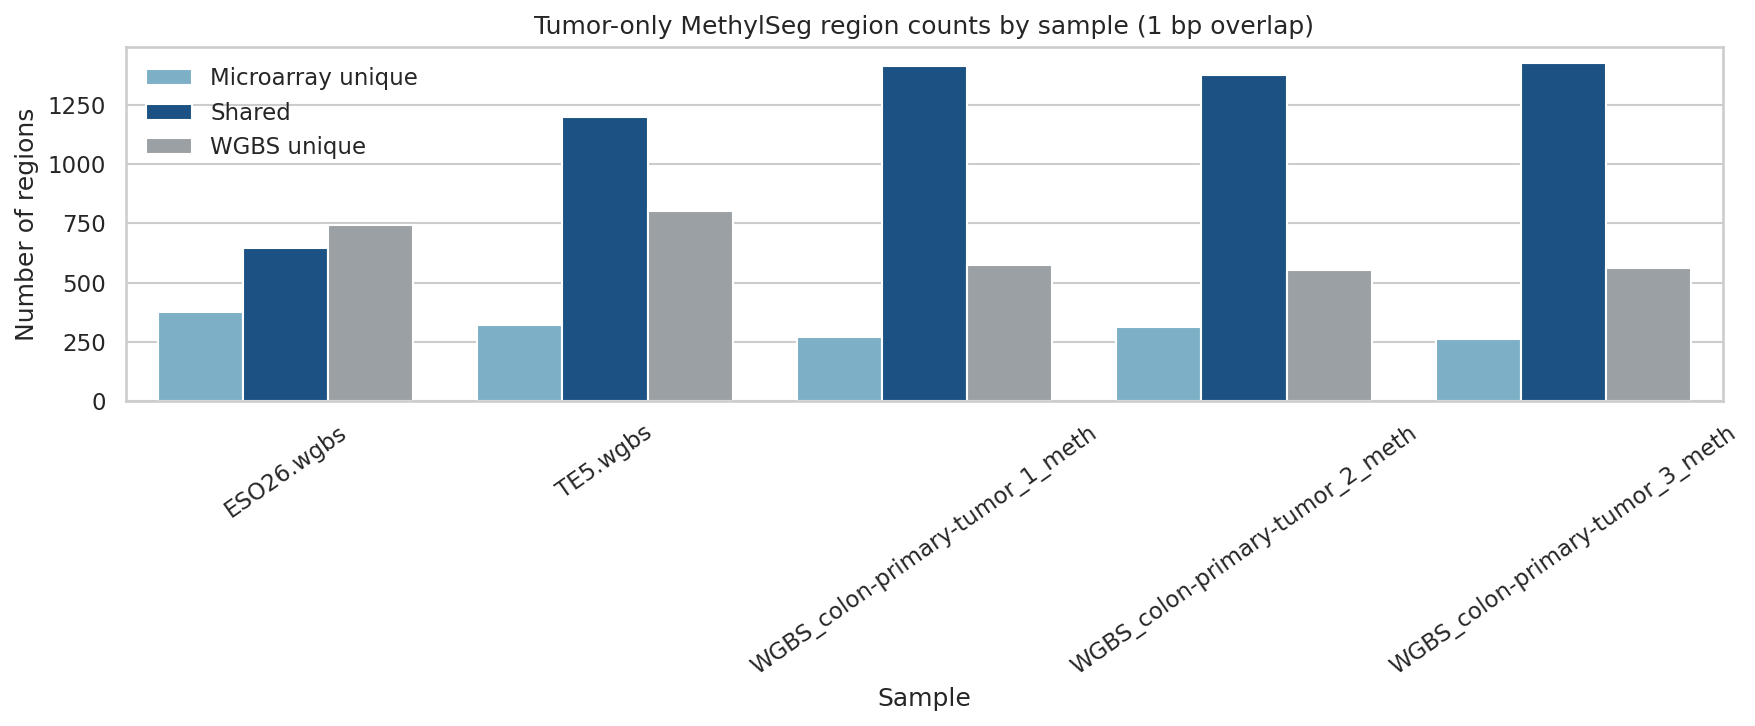

In [5]:
count_plot_df = sample_summary_df.loc[:, [
    "sample_id",
    "hm450k_shared_regions",
    "hm450k_microarray_unique_regions",
    "wgbs_microarray_missed_regions",
]].rename(columns={
    "hm450k_shared_regions": "shared",
    "hm450k_microarray_unique_regions": "microarray_unique",
    "wgbs_microarray_missed_regions": "microarray_missed",
})
count_plot_df = count_plot_df.melt(id_vars="sample_id", var_name="category", value_name="n_regions")
count_plot_df["category"] = pd.Categorical(count_plot_df["category"], categories=CATEGORY_ORDER, ordered=True)
count_plot_df["category_label"] = count_plot_df["category"].map(CATEGORY_LABELS)

palette_by_label = {CATEGORY_LABELS[key]: value for key, value in CATEGORY_COLORS.items()}

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=count_plot_df,
    x="sample_id",
    y="n_regions",
    hue="category_label",
    hue_order=[CATEGORY_LABELS[c] for c in CATEGORY_ORDER],
    palette=palette_by_label,
    ax=ax,
)
ax.set_title(f"Tumor-only MethylSeg region counts by sample ({threshold_label(THRESHOLD_REQ)})")
ax.set_xlabel("Sample")
ax.set_ylabel("Number of regions")
ax.tick_params(axis="x", rotation=35)
ax.legend(title=None, frameon=False)
fig.tight_layout()
savefig_if_enabled(fig, "tumor_overlap_counts_by_sample.png")
plt.show()


## Selected-sample and aggregate HM450K-centered summary


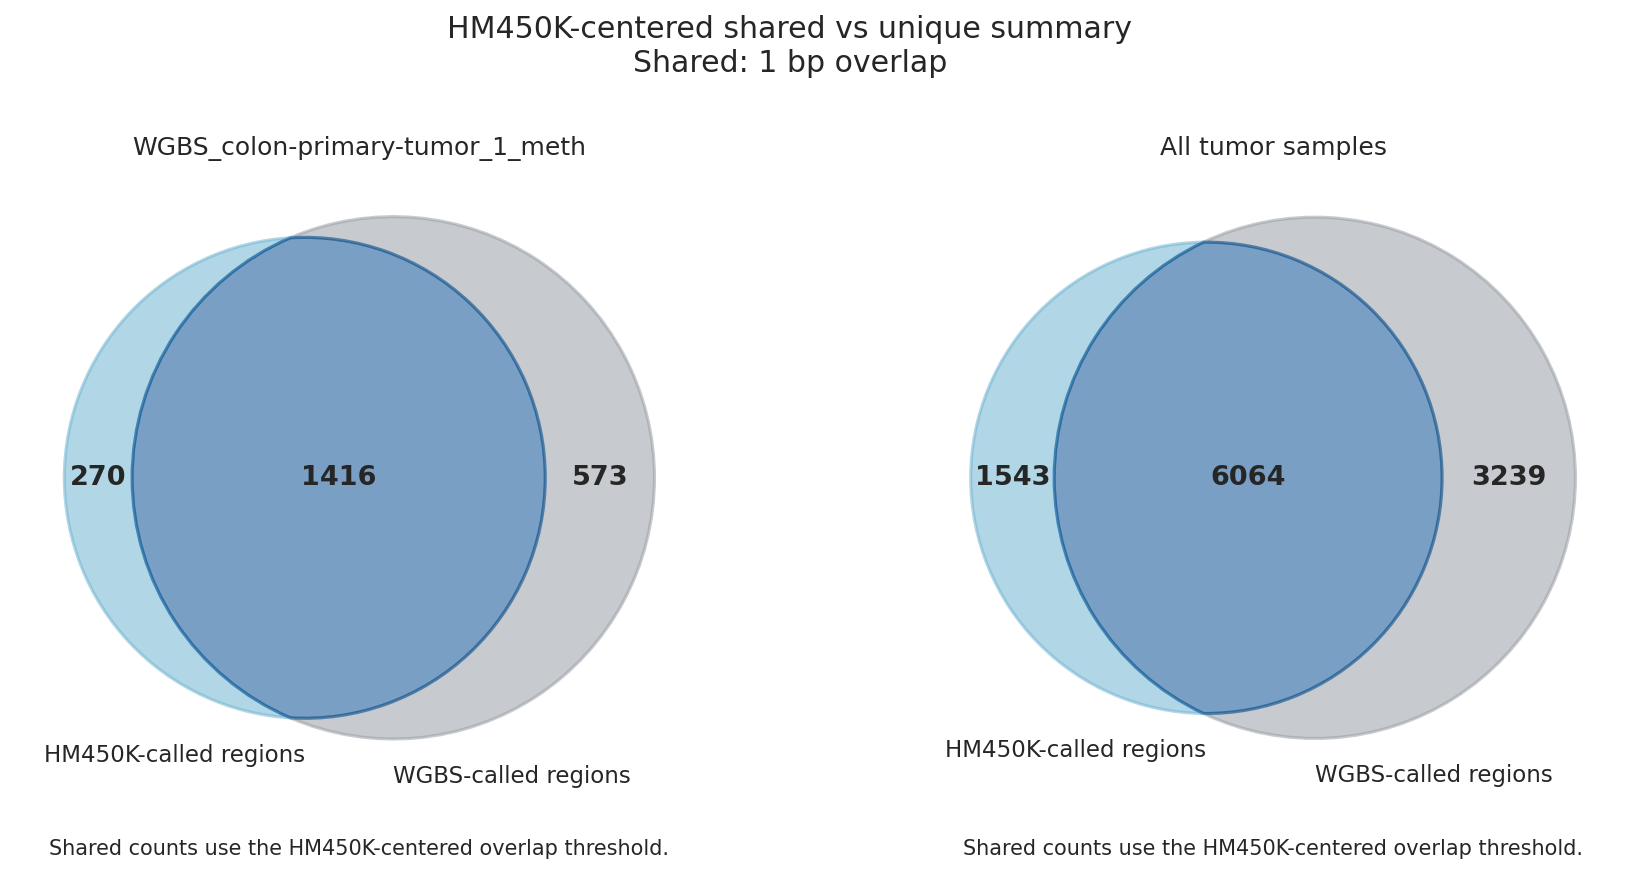

,threshold_kind,threshold_value,hm450k_total_regions,hm450k_shared_regions,hm450k_microarray_unique_regions,wgbs_total_regions,wgbs_microarray_missed_regions,hm450k_total_bp,hm450k_shared_bp,hm450k_microarray_unique_bp,wgbs_total_bp,wgbs_microarray_missed_bp
sample_id,,,,,,,,,,,,
WGBS_colon-primary-tumor_1_meth,bp,1,1686,1416,270,1571,573,683734181,618855465,64878716,1712161457,324846478
All tumor samples,bp,1,7607,6064,1543,7815,3239,3067418863,2671341060,396077803,7512930767,1882197030


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_overlap_venn(axes[0], selected_summary)
axes[0].set_title(SELECTED_SAMPLE)
plot_overlap_venn(axes[1], aggregate_summary)
axes[1].set_title("All tumor samples")
fig.suptitle(
    "HM450K-centered shared vs unique summary\n"
    f"Shared: {threshold_label(THRESHOLD_REQ)}",
    y=0.97,
)
fig.subplots_adjust(top=0.80, wspace=0.28)
savefig_if_enabled(fig, "hm450k_centered_venn_summaries.png")
plt.show()

pd.DataFrame([selected_summary, aggregate_summary]).set_index("sample_id")


## Colon replicate overlap patterns

The two platform-specific panels below are true three-set Venn diagrams across the colon tumor replicates. 
The aggregate six-sample view uses a membership-summary panel instead of a literal six-circle Venn because 
`matplotlib-venn` only supports up to three sets and the six-set membership matrix is much more readable.


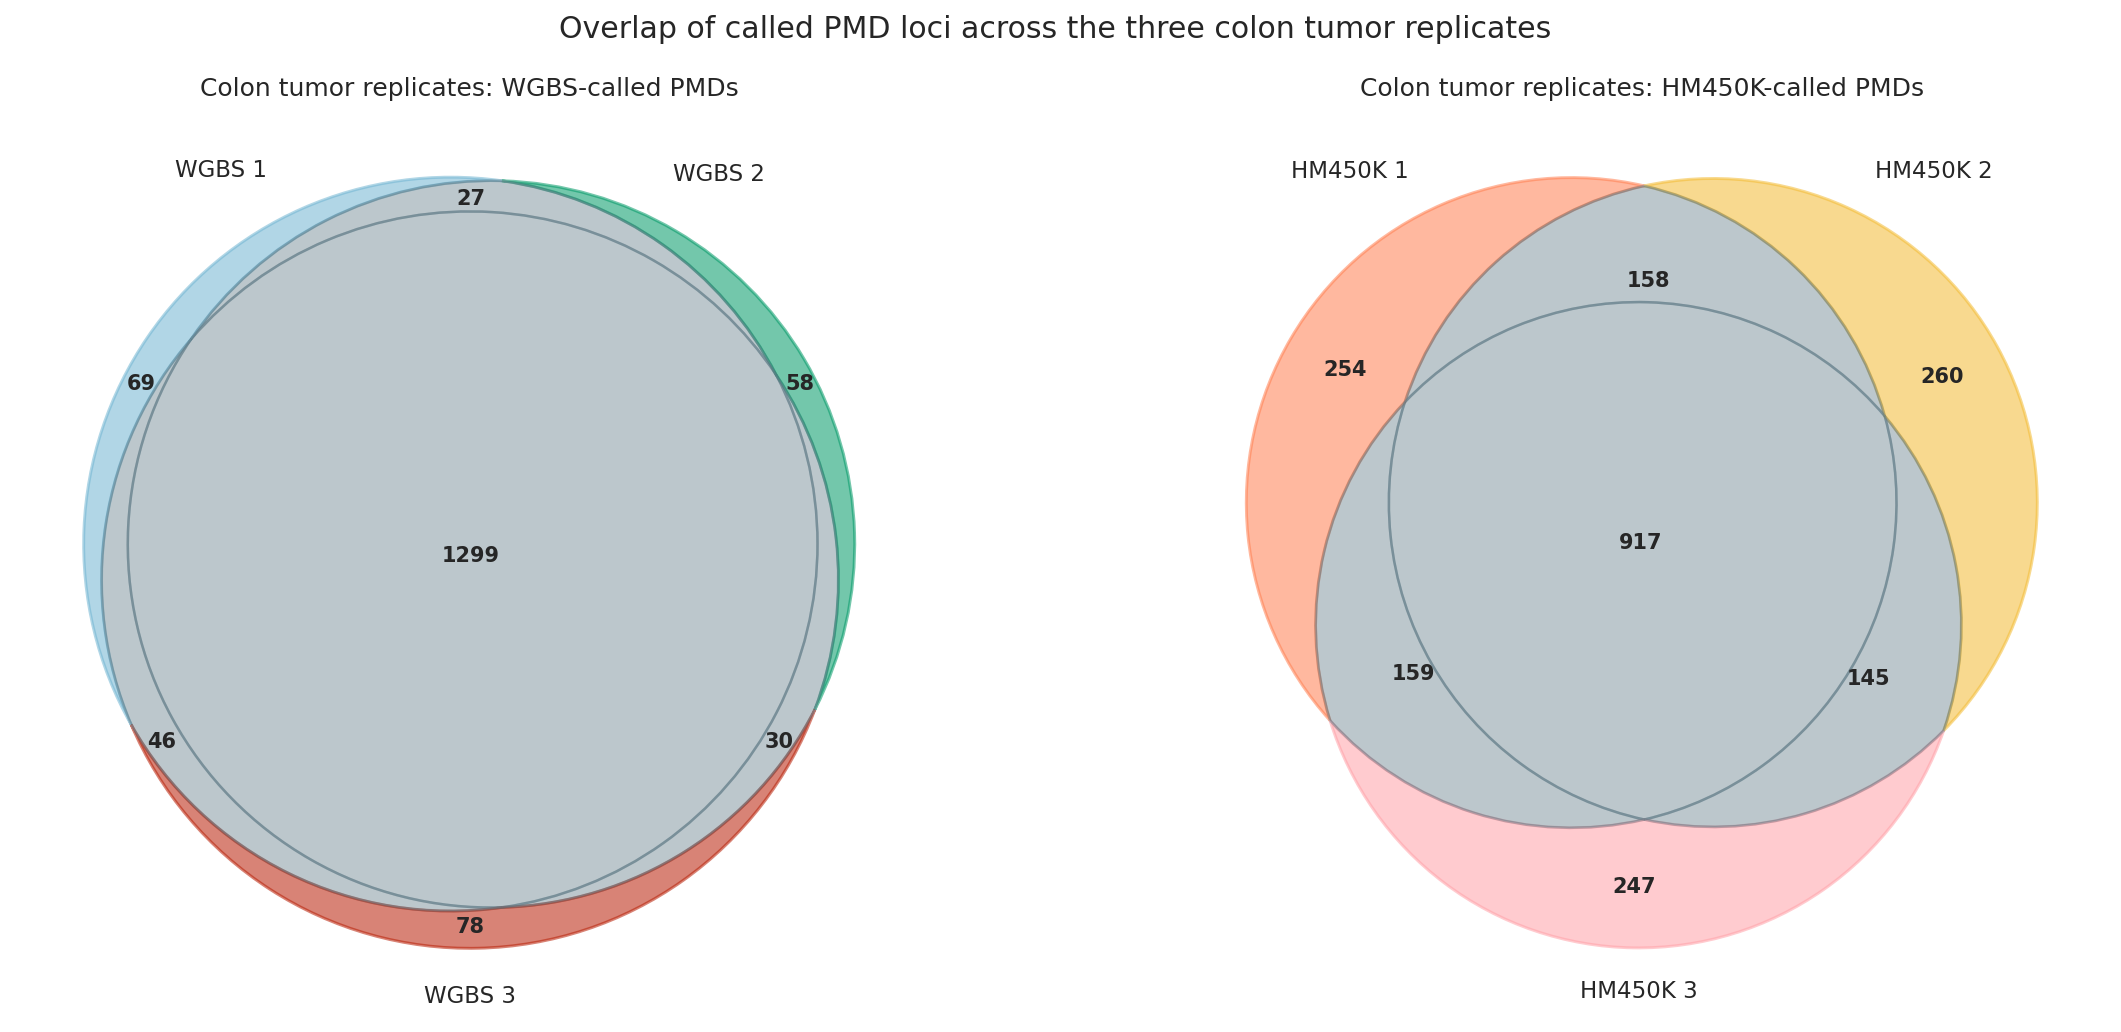

/tmp/ipykernel_1527661/2439606109.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


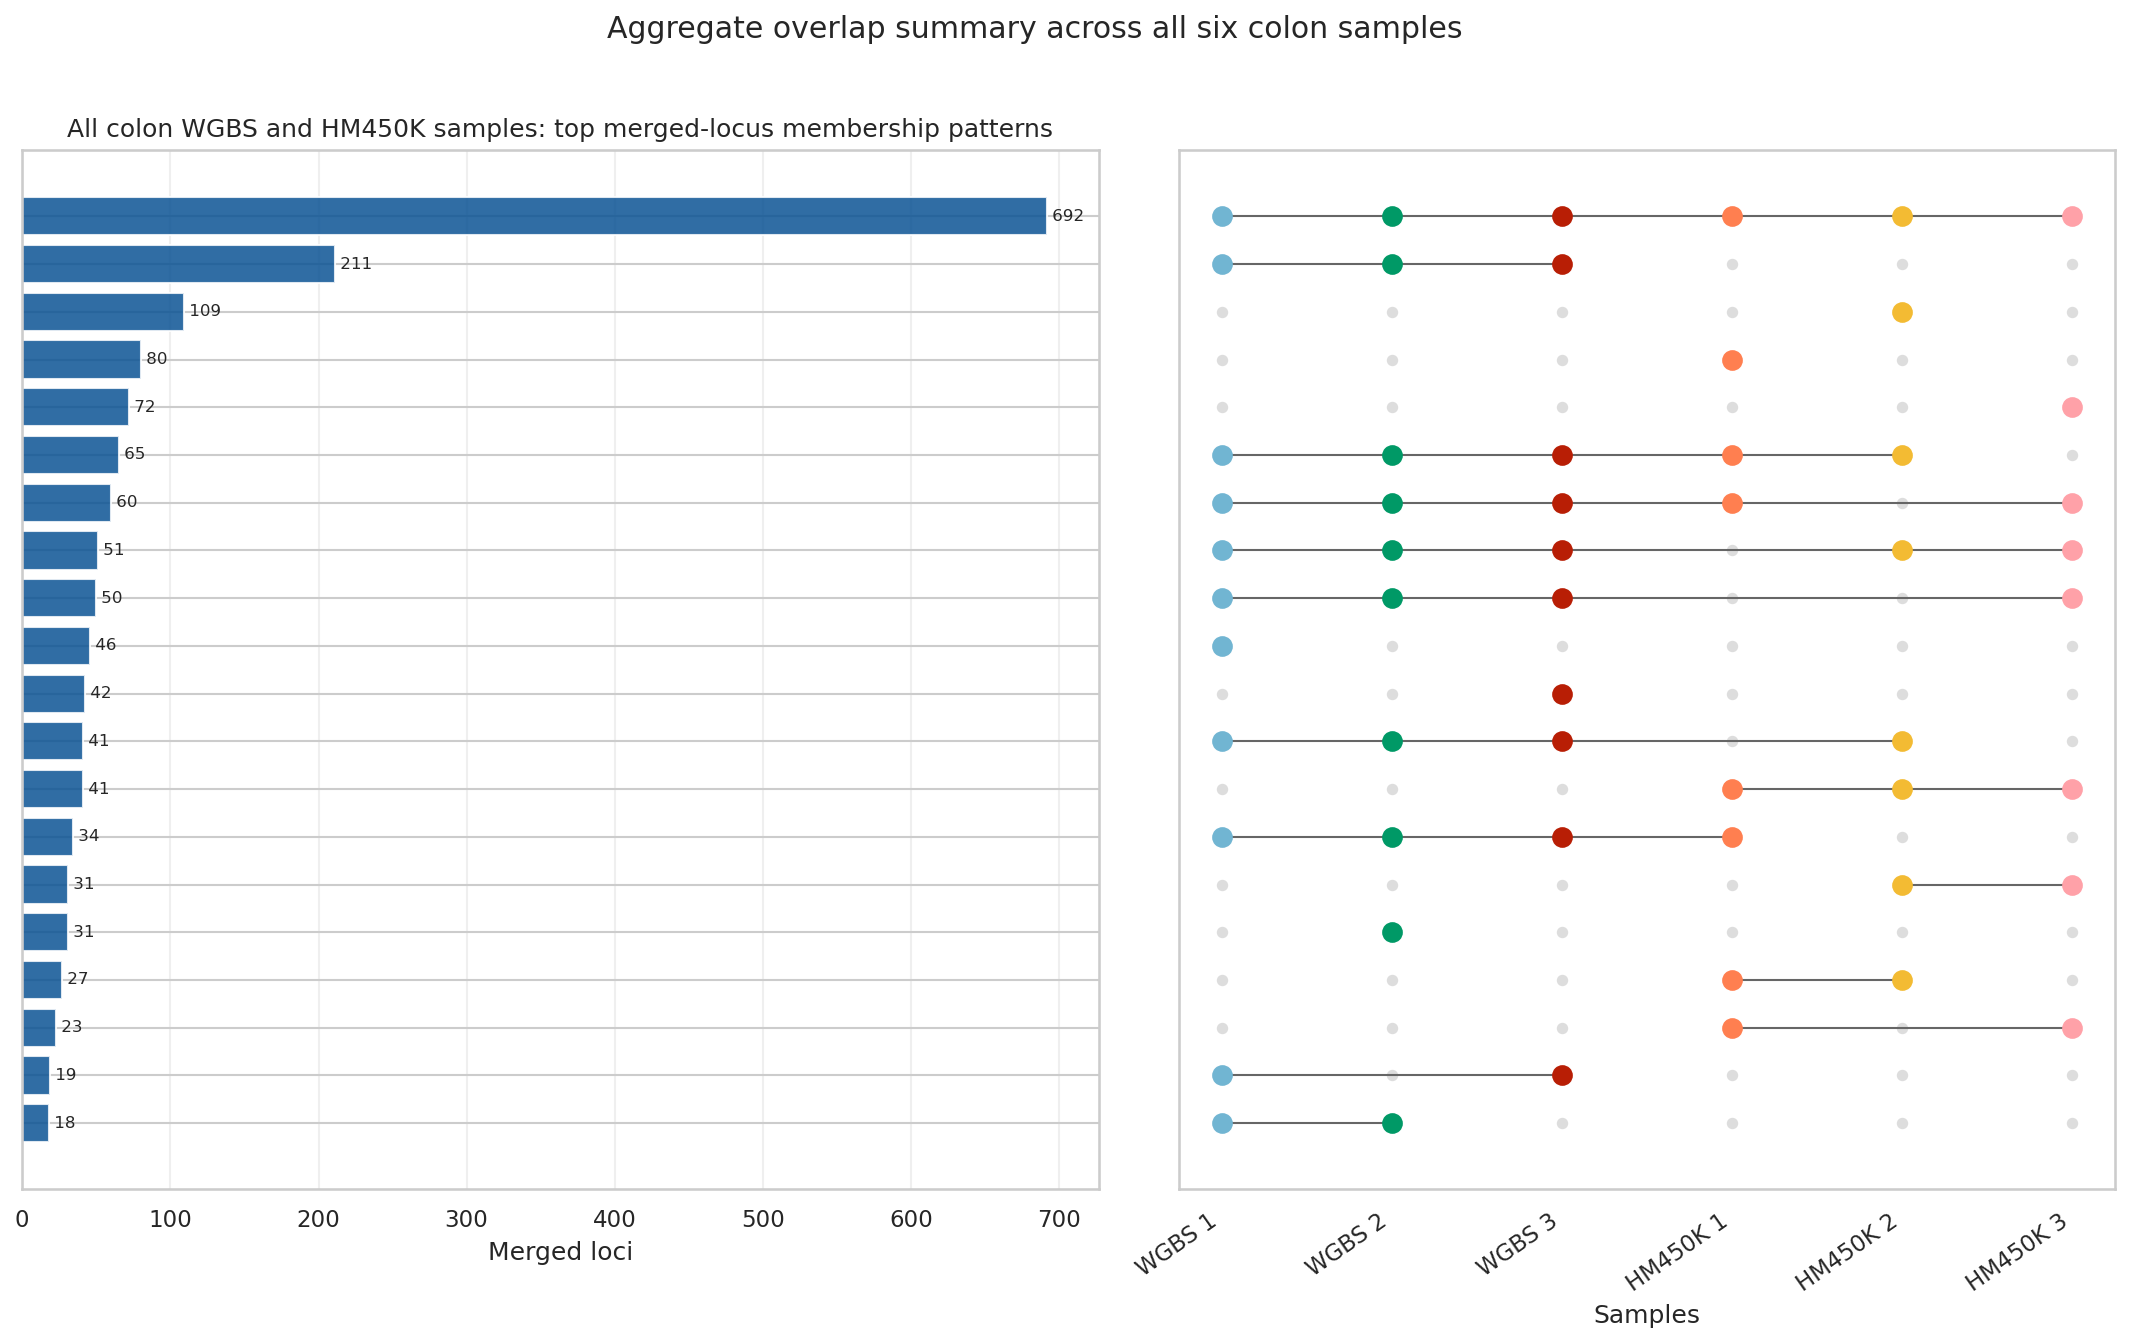

,subset_key,n_loci,WGBS 1,WGBS 2,WGBS 3,HM450K 1,HM450K 2,HM450K 3,n_sets,label
0,111111,692,True,True,True,True,True,True,6,WGBS 1 + WGBS 2 + WGBS 3 + HM450K 1 + HM450K 2...
1,111000,211,True,True,True,False,False,False,3,WGBS 1 + WGBS 2 + WGBS 3
2,000010,109,False,False,False,False,True,False,1,HM450K 2
3,000100,80,False,False,False,True,False,False,1,HM450K 1
4,000001,72,False,False,False,False,False,True,1,HM450K 3
5,111110,65,True,True,True,True,True,False,5,WGBS 1 + WGBS 2 + WGBS 3 + HM450K 1 + HM450K 2
6,111101,60,True,True,True,True,False,True,5,WGBS 1 + WGBS 2 + WGBS 3 + HM450K 1 + HM450K 3
7,111011,51,True,True,True,False,True,True,5,WGBS 1 + WGBS 2 + WGBS 3 + HM450K 2 + HM450K 3
8,111001,50,True,True,True,False,False,True,4,WGBS 1 + WGBS 2 + WGBS 3 + HM450K 3
9,100000,46,True,False,False,False,False,False,1,WGBS 1


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
WGBS_REPLICATE_VENN_LABEL_POSITIONS = {
    "100": (-0.48, 0.25),
    "010": (0.48, 0.25),
    "001": (0.00, -0.54),
    "110": (0.00, 0.52),
    "101": (-0.45, -0.27),
    "011": (0.45, -0.27),
    "111": (0.00, 0.00),
}
plot_replicate_venn3(
    axes[0],
    wgbs_colon_subset_df,
    wgbs_colon_set_names,
    WGBS_REPLICATE_COLORS,
    "Colon tumor replicates: WGBS-called PMDs",
    subset_label_positions=WGBS_REPLICATE_VENN_LABEL_POSITIONS,
)
plot_replicate_venn3(
    axes[1],
    hm450k_colon_subset_df,
    hm450k_colon_set_names,
    HM450K_REPLICATE_COLORS,
    "Colon tumor replicates: HM450K-called PMDs",
)
fig.suptitle("Overlap of called PMD loci across the three colon tumor replicates", y=0.98)
fig.tight_layout()
savefig_if_enabled(fig, "colon_replicate_platform_venn3.png")
plt.show()

fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.08)
bar_ax = fig.add_subplot(gs[0, 0])
matrix_ax = fig.add_subplot(gs[0, 1], sharey=bar_ax)
all_set_color_map = {
    **{name: color for name, color in zip(wgbs_colon_set_names, WGBS_REPLICATE_COLORS)},
    **{name: color for name, color in zip(hm450k_colon_set_names, HM450K_REPLICATE_COLORS)},
}
plot_multiset_membership(
    bar_ax,
    matrix_ax,
    all_colon_subset_df,
    all_colon_set_names,
    all_set_color_map,
    "All colon WGBS and HM450K samples: top merged-locus membership patterns",
    max_rows=20,
)
fig.suptitle("Aggregate overlap summary across all six colon samples", y=0.98)
fig.tight_layout()
savefig_if_enabled(fig, "colon_replicate_all_samples_membership.png")
plt.show()

all_colon_subset_df.head(20)


## Distribution figures for the selected sample and tumor aggregate

The HM450K probe-count histogram uses `450k_meth_ref.tsv` for all three categories, including `WGBS-unique`. The CpG-retention panel plots the fraction of WGBS CpGs still represented when moving to HM450K support in the same interval. Each view now includes overlapping histograms, category-wise boxplots, and a summary-statistics table for the selected sample and for all tumor samples together.


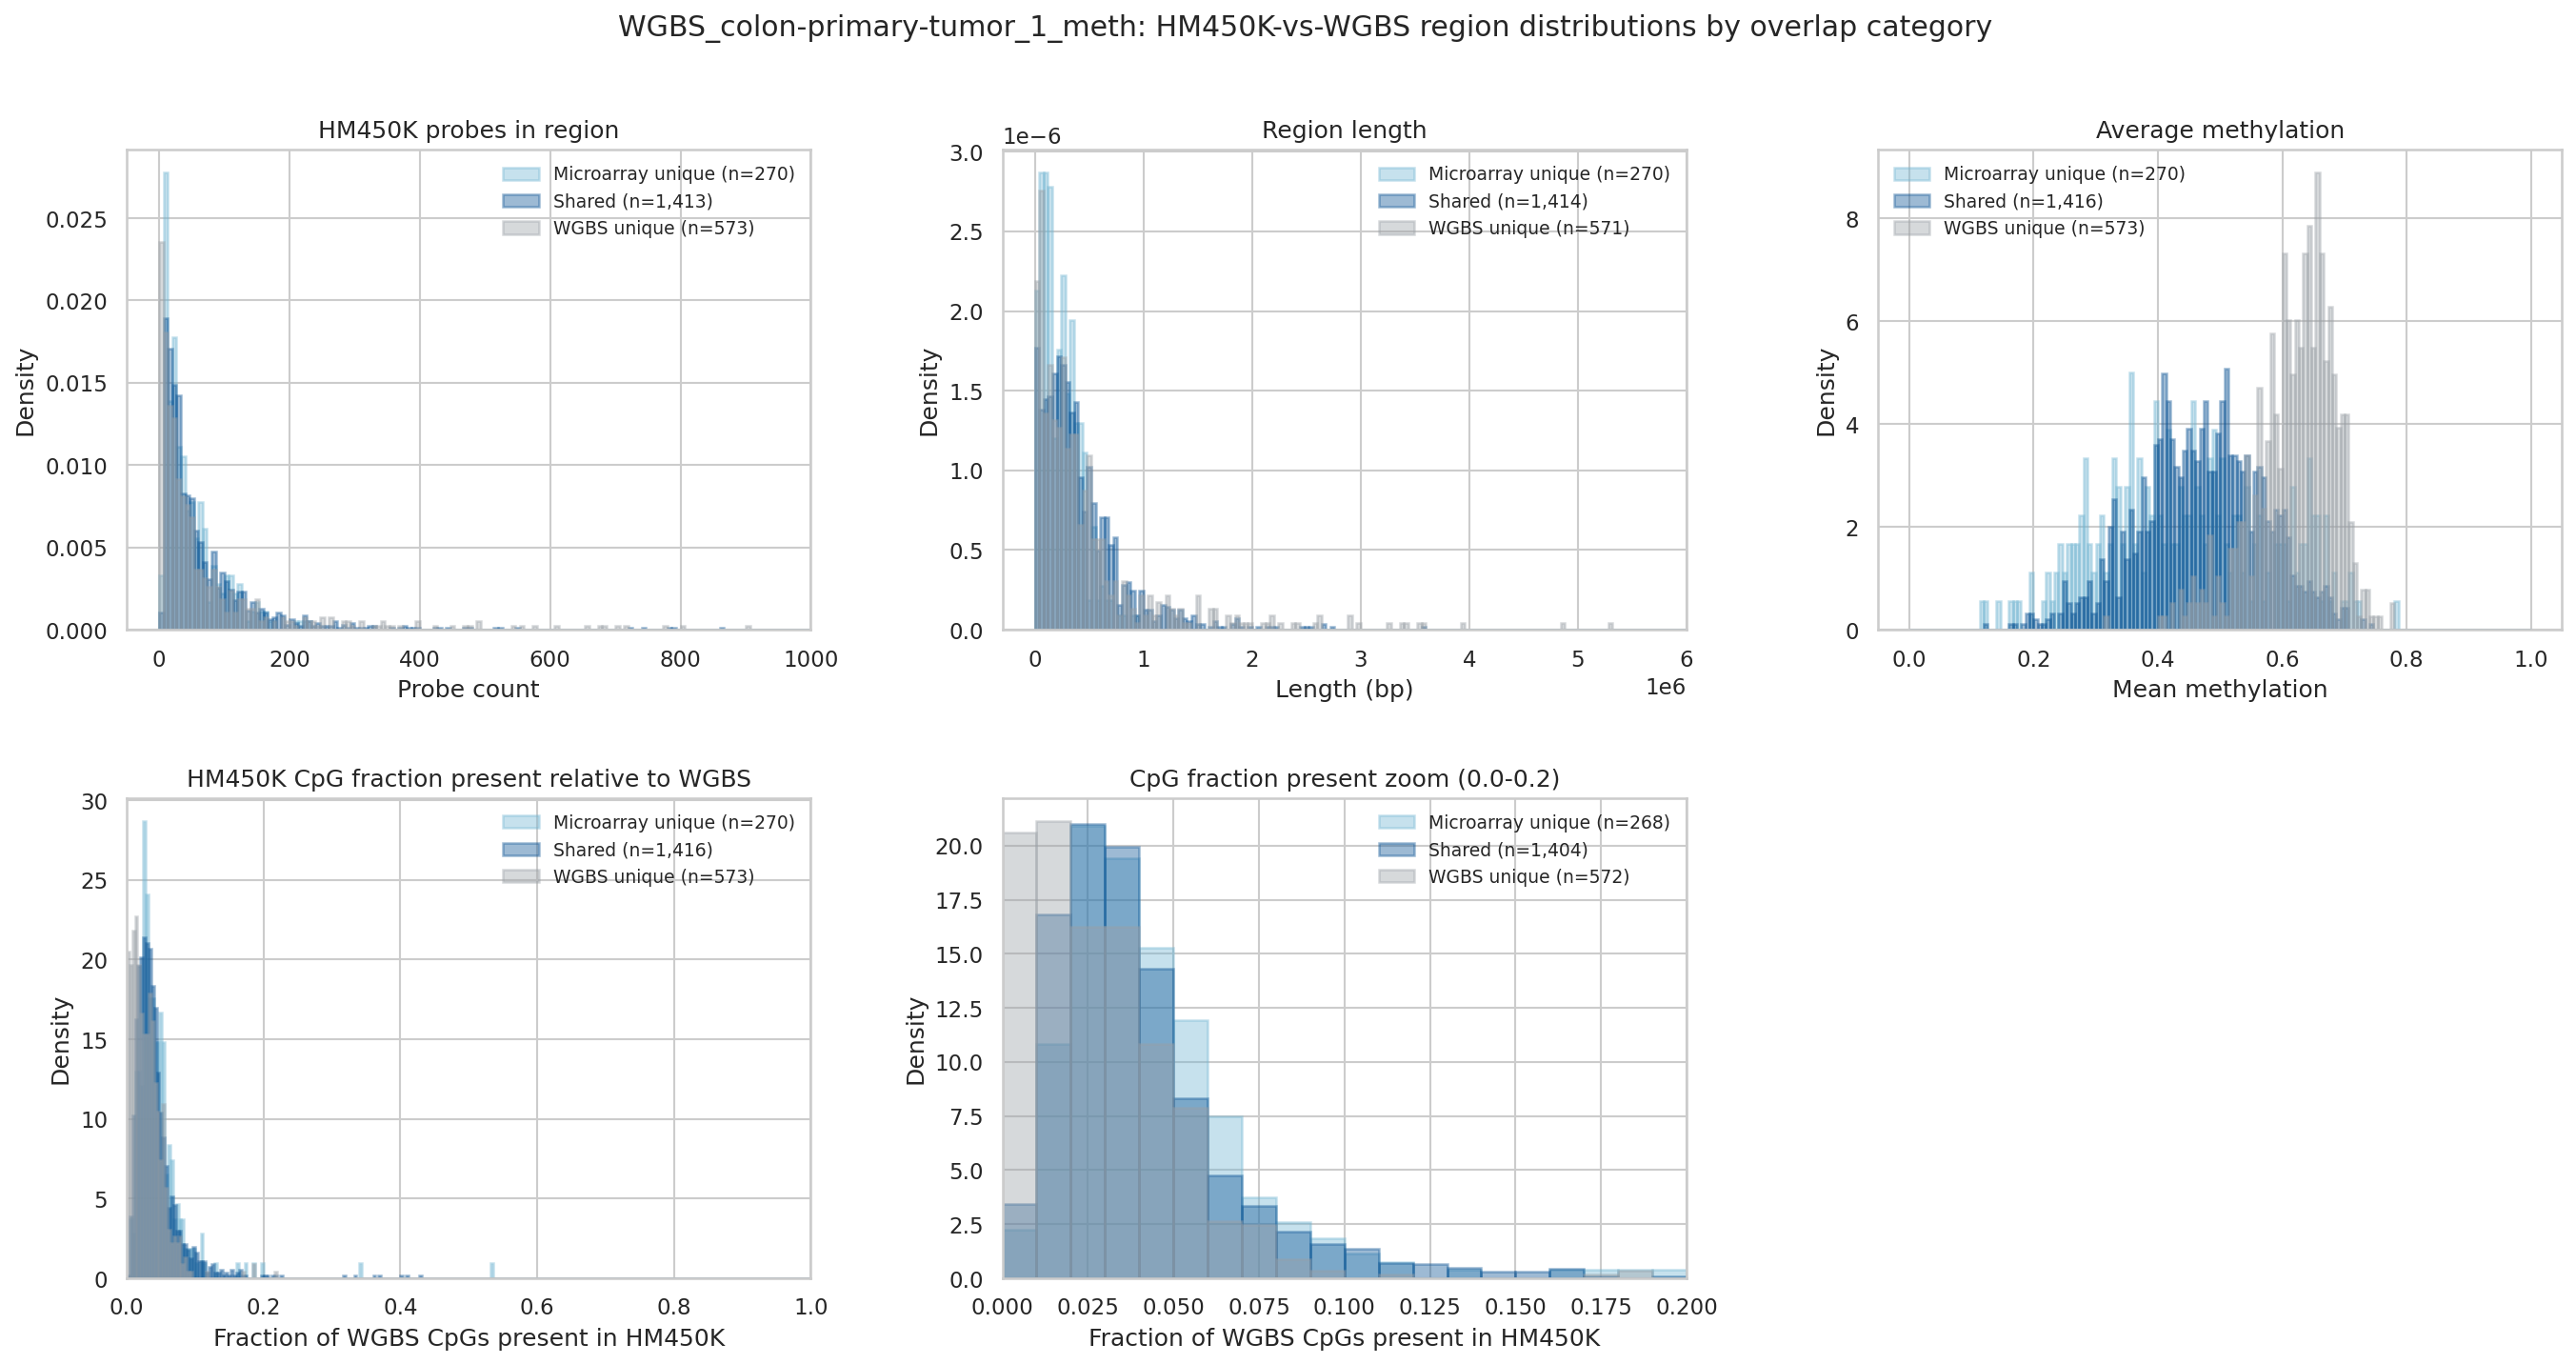

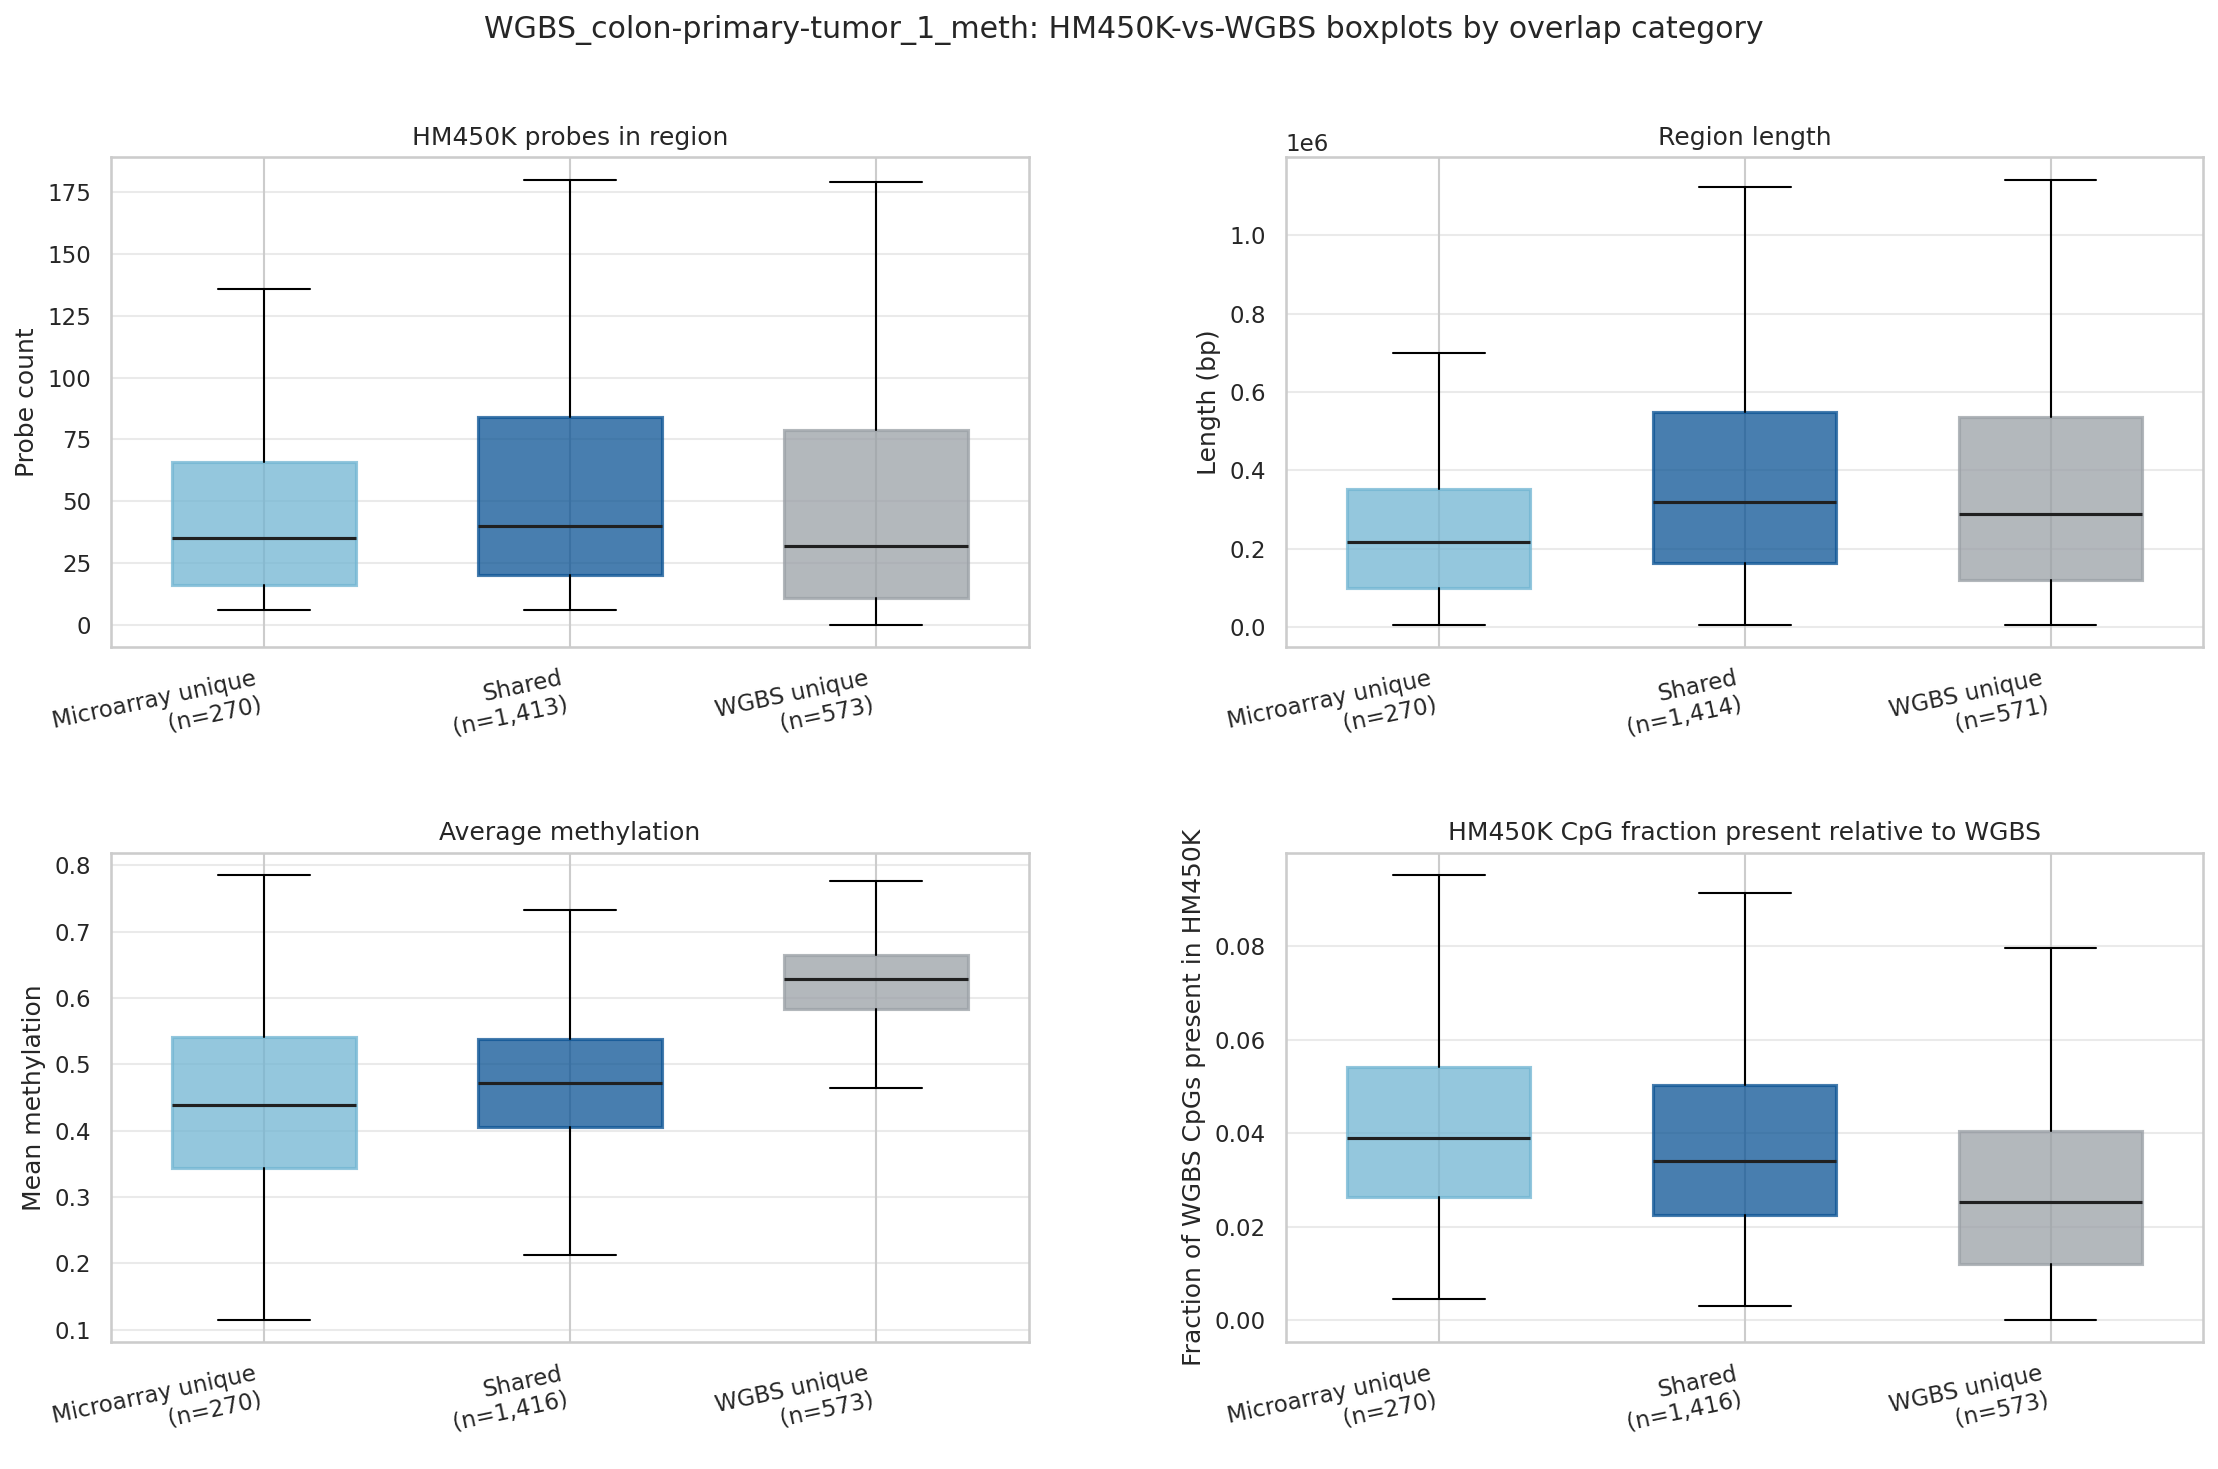

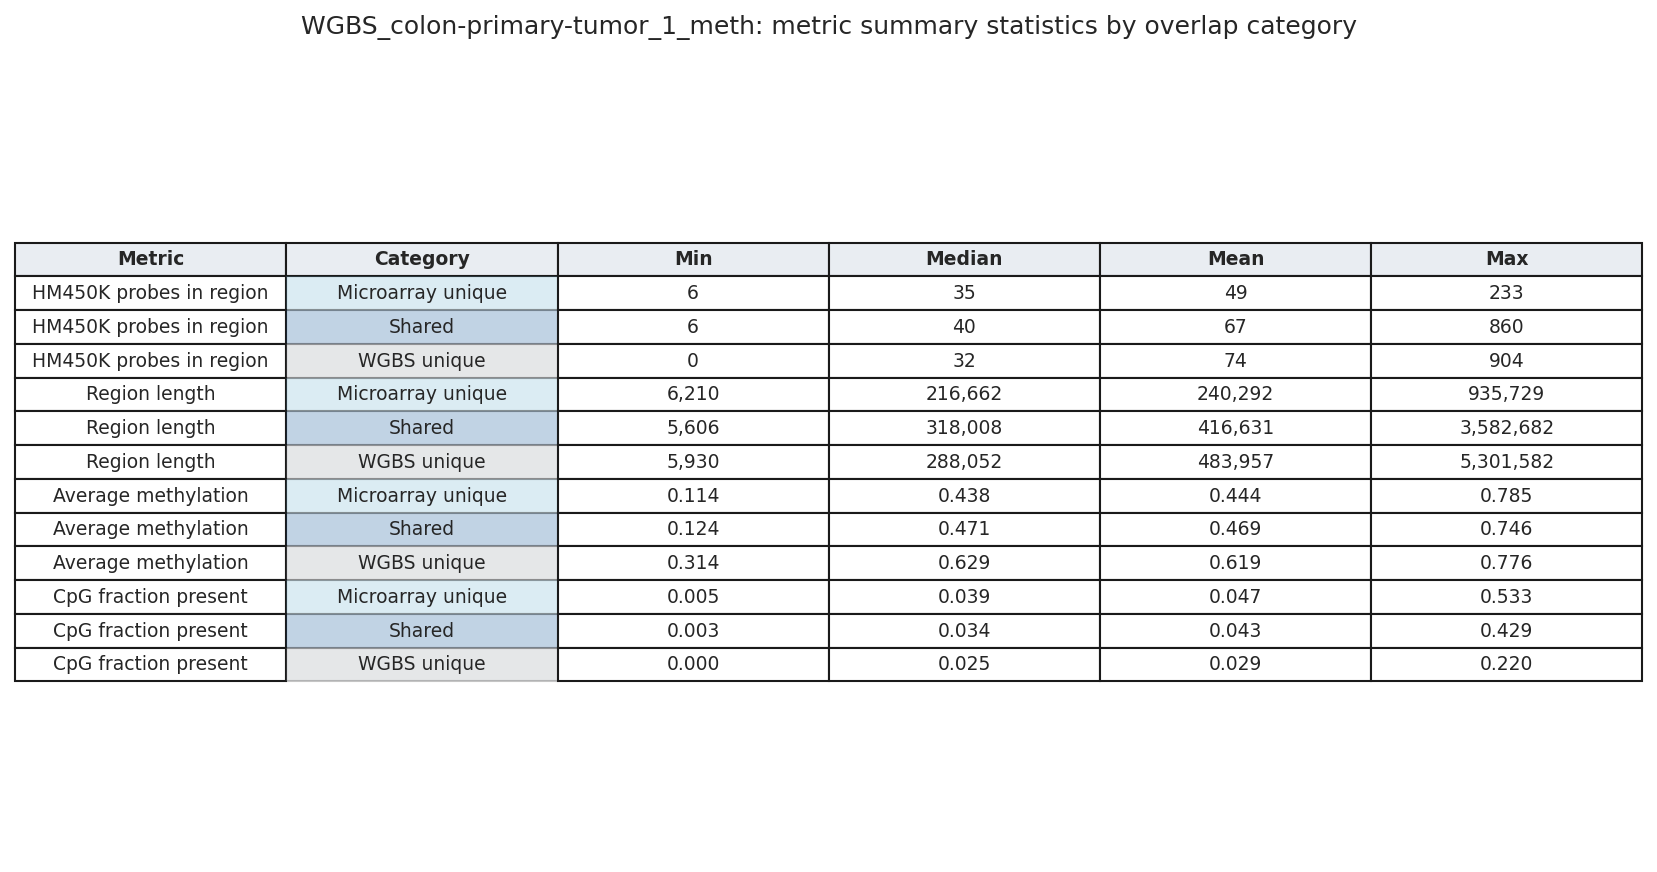

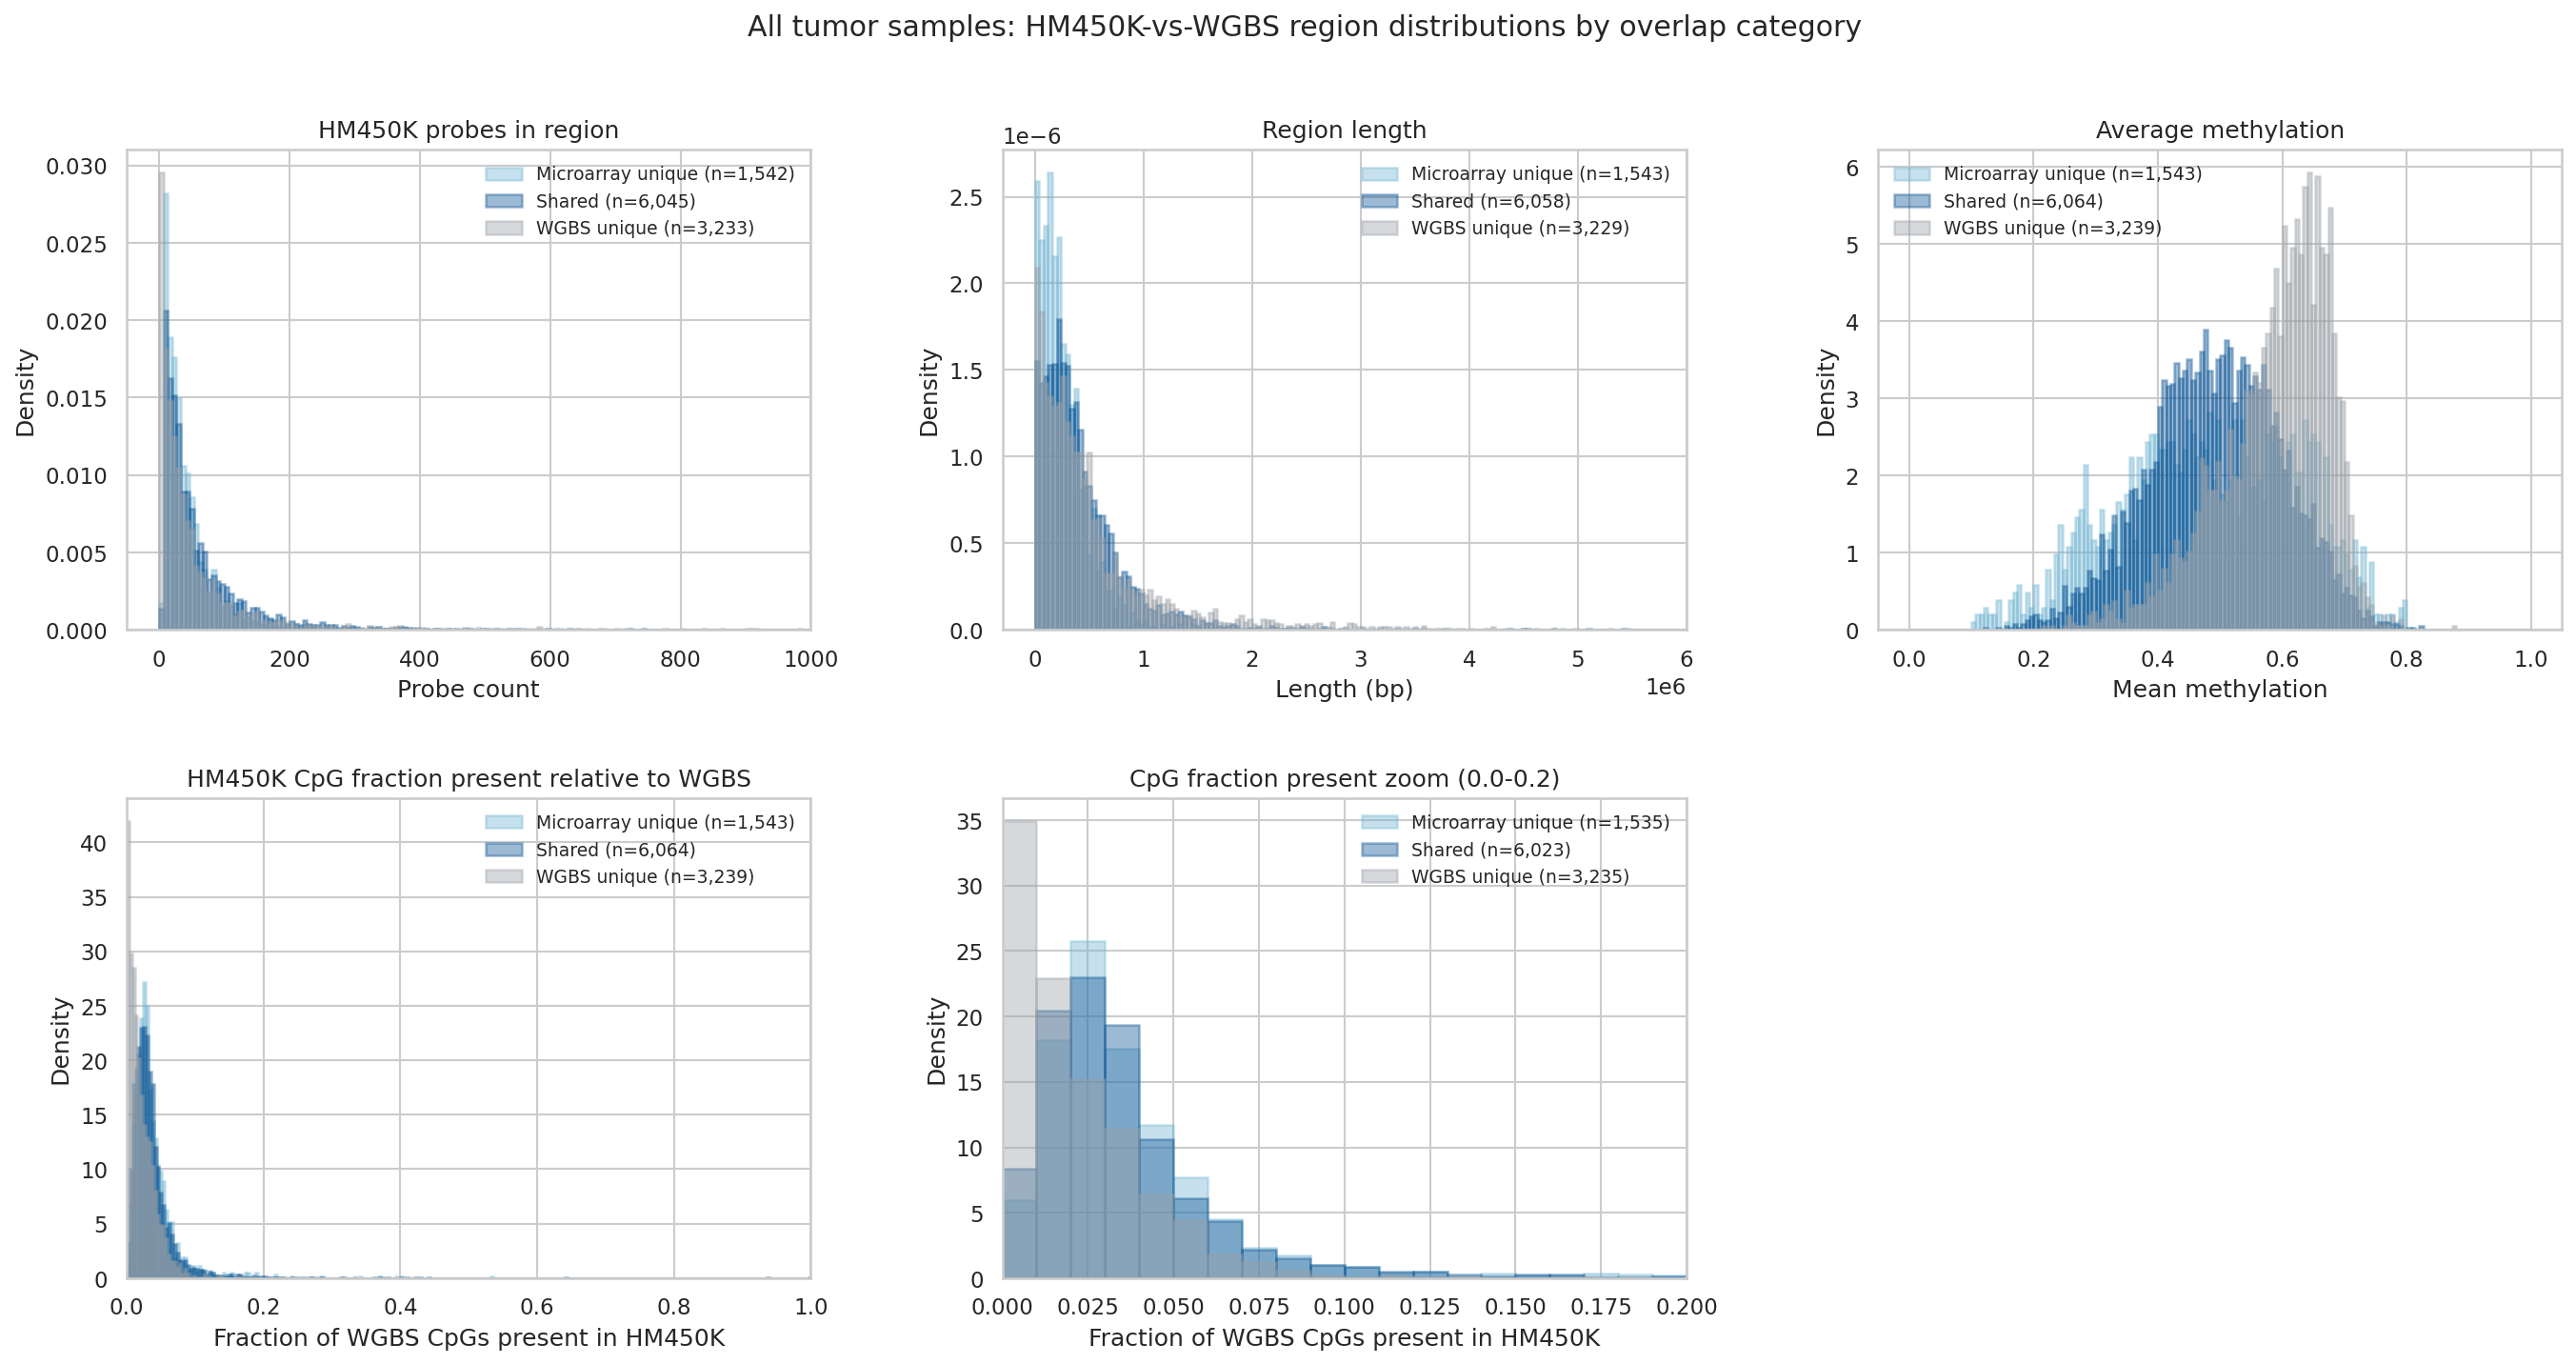

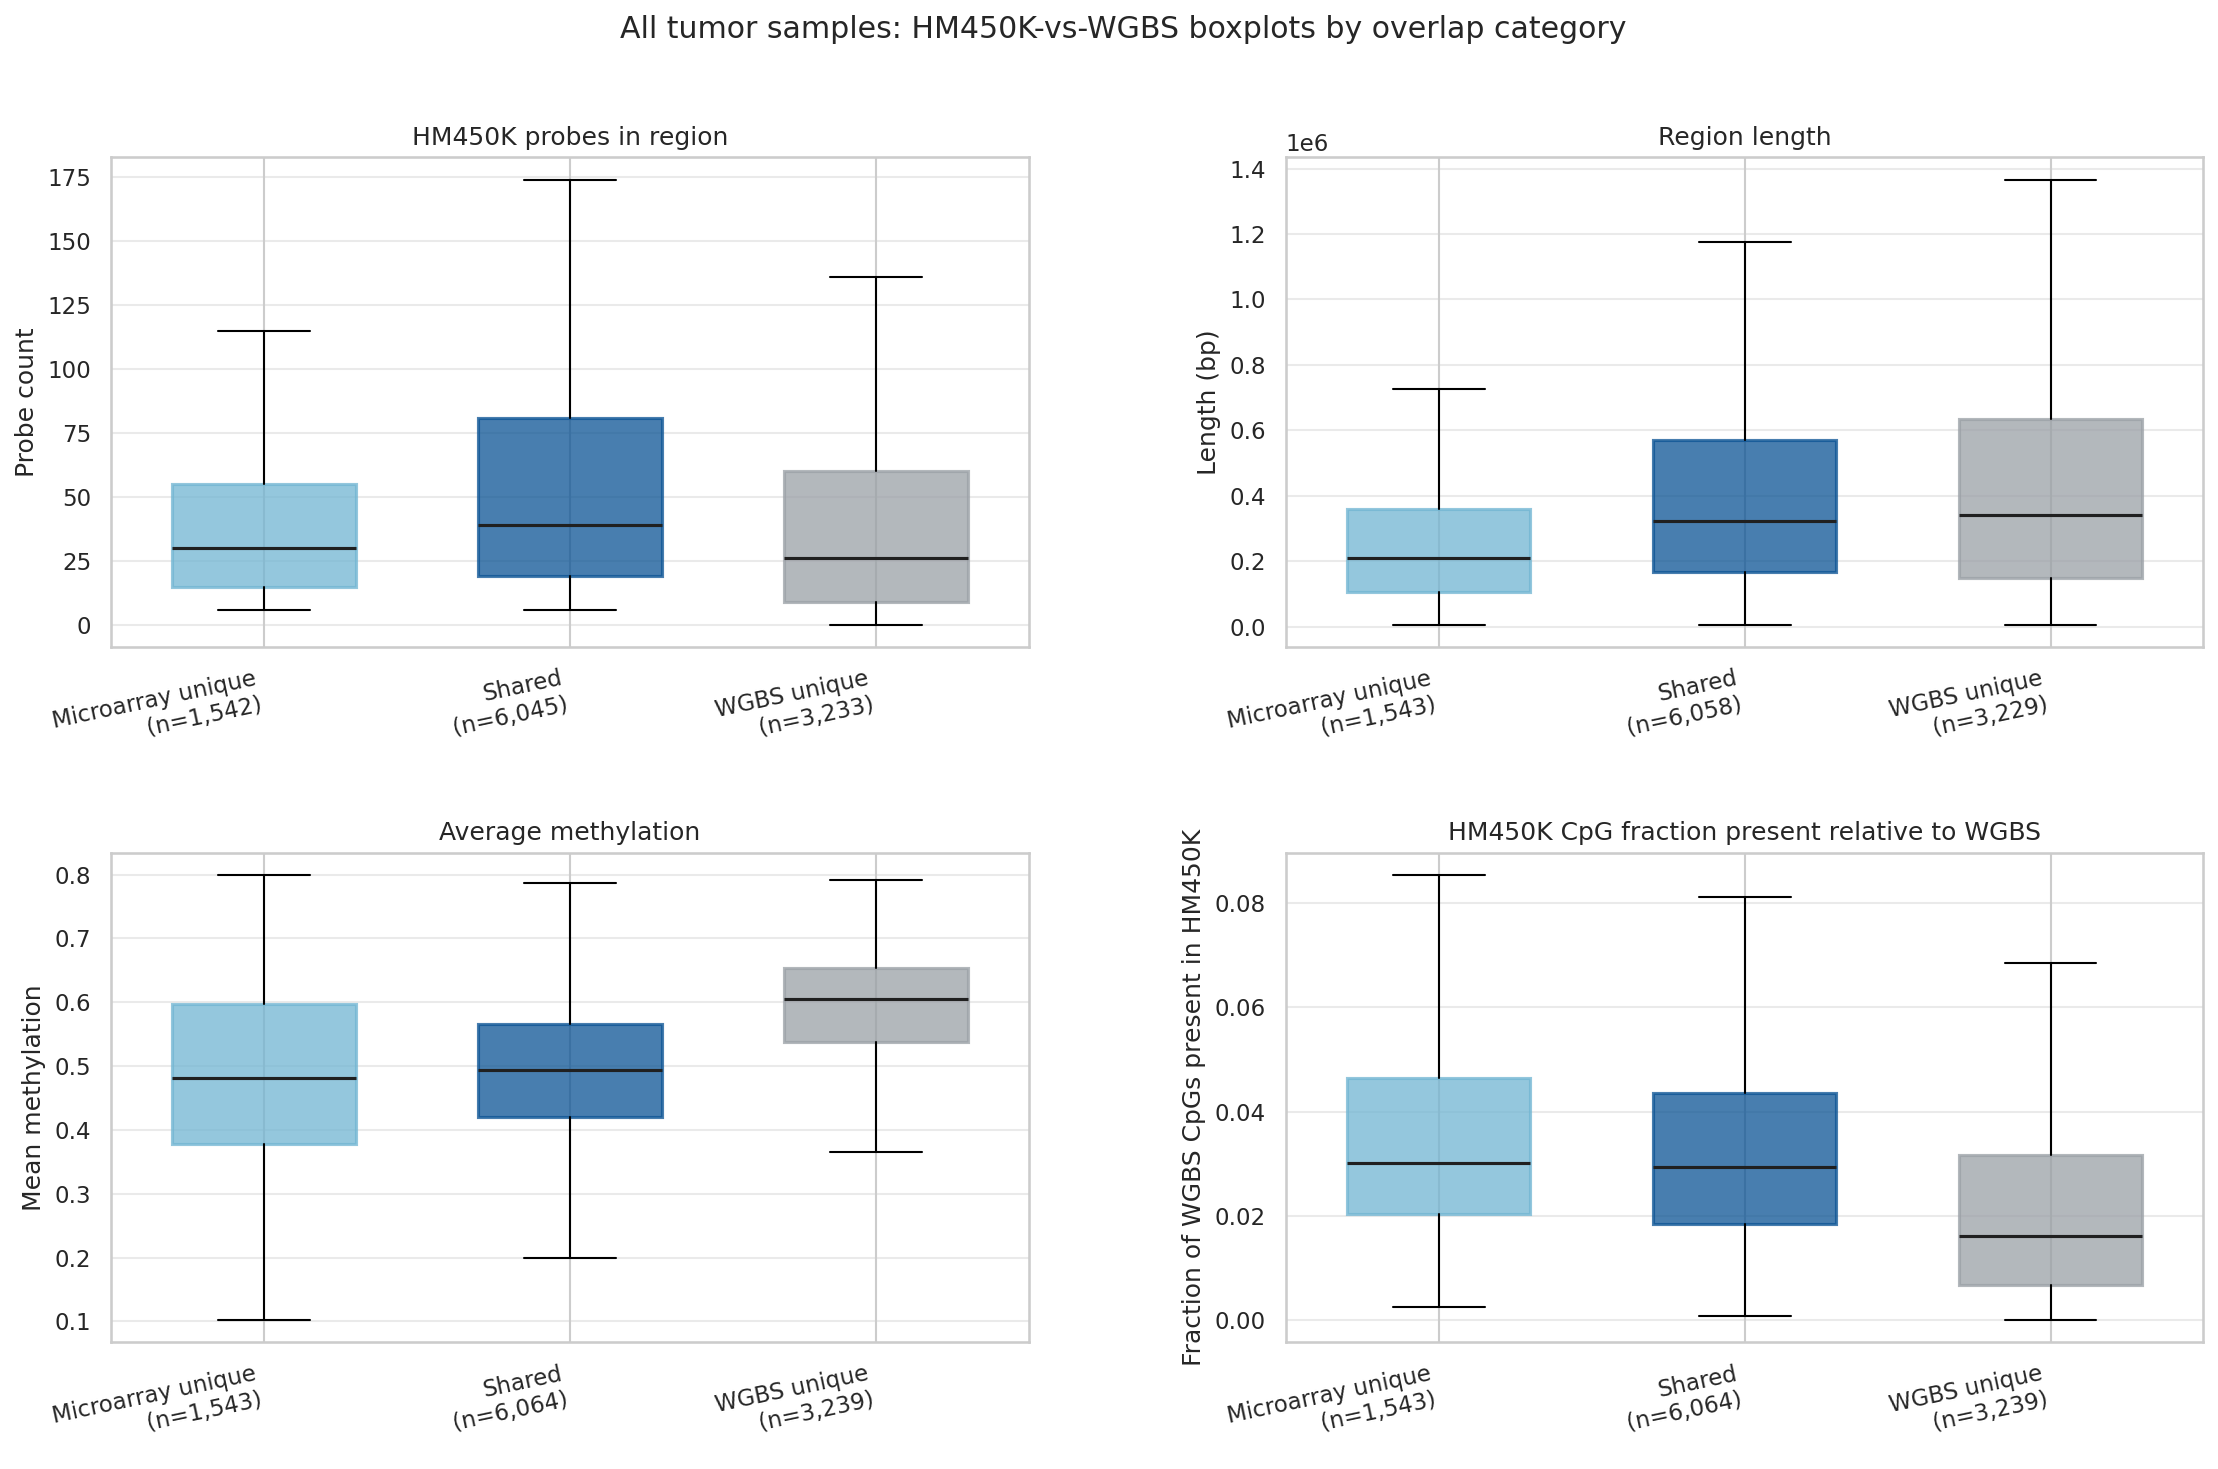

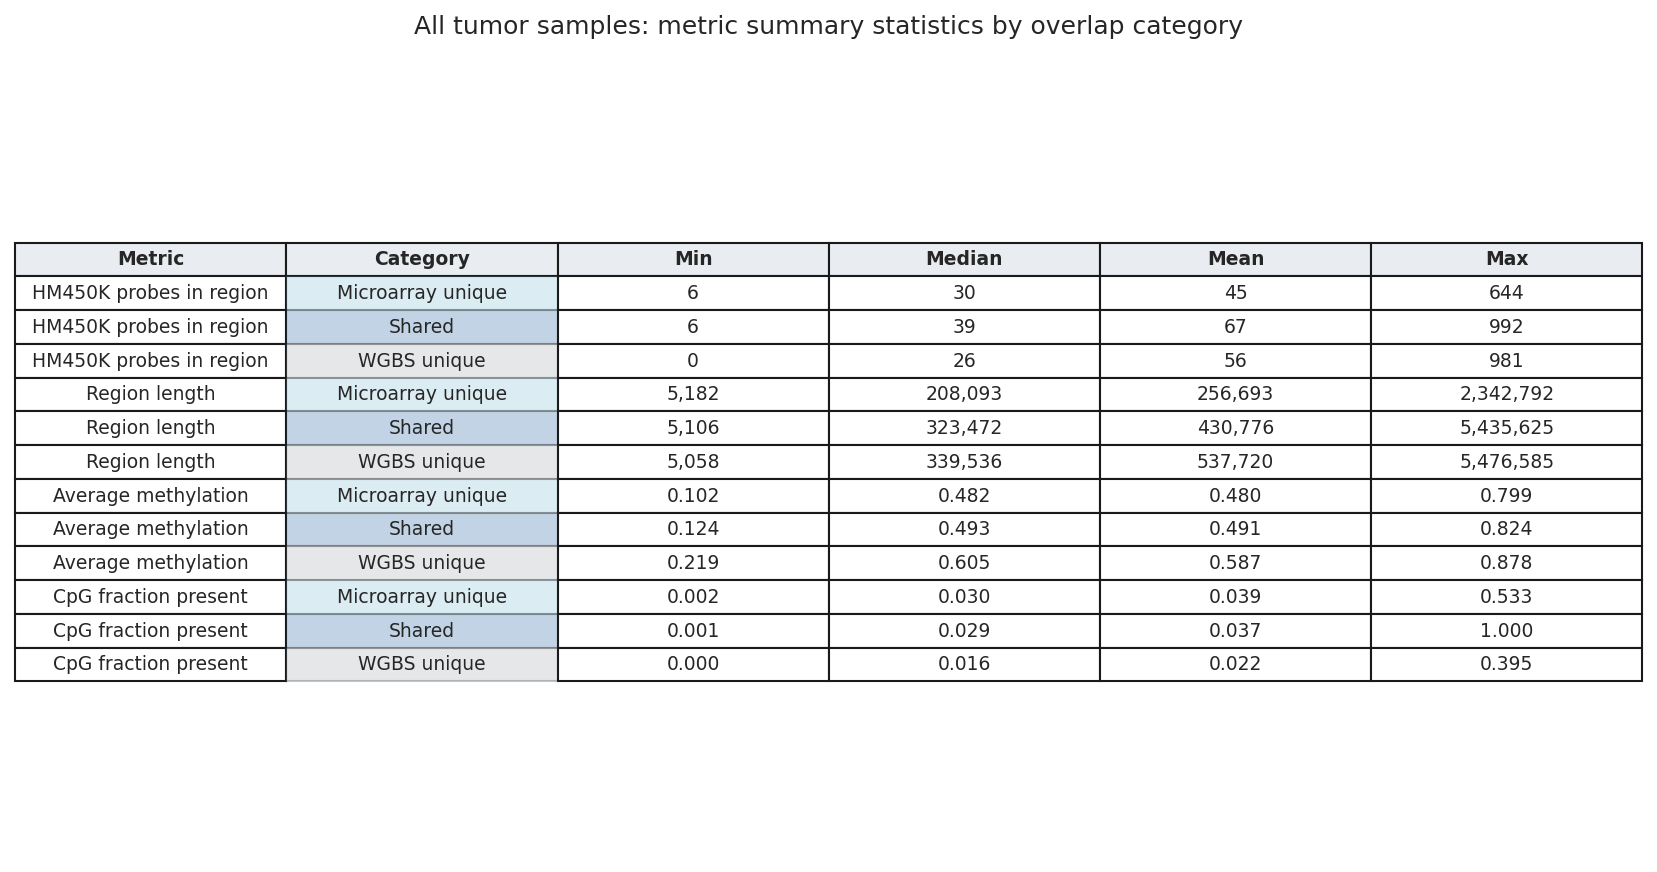

In [8]:
selected_histogram_df = histogram_df.loc[histogram_df["sample_id"] == SELECTED_SAMPLE].copy()
assert not selected_histogram_df.empty

selected_hist_fig, selected_hist_axes = plot_histogram_grid(
    selected_histogram_df,
    f"{SELECTED_SAMPLE}: HM450K-vs-WGBS region distributions by overlap category",
    f"{SELECTED_SAMPLE}.overlap_histograms.png",
)
plt.show()

selected_box_fig, selected_box_axes = plot_boxplot_grid(
    selected_histogram_df,
    f"{SELECTED_SAMPLE}: HM450K-vs-WGBS boxplots by overlap category",
    f"{SELECTED_SAMPLE}.overlap_boxplots.png",
)
plt.show()

selected_table_fig, selected_table_ax, selected_summary_table_df = plot_metric_summary_table(
    selected_histogram_df,
    f"{SELECTED_SAMPLE}: metric summary statistics by overlap category",
    f"{SELECTED_SAMPLE}.metric_summary_table.png",
)
plt.show()

cohort_hist_fig, cohort_hist_axes = plot_histogram_grid(
    histogram_df,
    "All tumor samples: HM450K-vs-WGBS region distributions by overlap category",
    "tumor_overlap_histograms.png",
)
plt.show()

cohort_box_fig, cohort_box_axes = plot_boxplot_grid(
    histogram_df,
    "All tumor samples: HM450K-vs-WGBS boxplots by overlap category",
    "tumor_overlap_boxplots.png",
)
plt.show()

cohort_table_fig, cohort_table_ax, cohort_summary_table_df = plot_metric_summary_table(
    histogram_df,
    "All tumor samples: metric summary statistics by overlap category",
    "tumor_metric_summary_table.png",
)
plt.show()


## Notes

- `Shared` is evaluated from the HM450K perspective using `THRESHOLD_REQ`.
- `Microarray unique` comes from HM450K-called regions without a qualifying WGBS overlap.
- `WGBS unique` comes from WGBS-called regions without a qualifying HM450K overlap.
- Average methylation uses the platform-appropriate saved methylation track for each category.
